In [1]:
import ffmpeg as ffmpeg
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib
from pathlib import Path

In [6]:
def resolve_path(p) -> Path:
    clean = str(p).strip().strip('"').replace("\\", "/").lstrip("/")
    return lab_drive / clean

def load_sessions(sheet_path: str | Path, date_col: str = "date") -> pd.DataFrame:
    df = pd.read_csv(sheet_path)

    sessions = pd.DataFrame({
        "session_id": df[date_col].astype(str),
        "beh_csv": [resolve_path(p) for p in df["beh_csv_path"]],
        "sleap_csv": [resolve_path(p) for p in df["sleap_csv_path"]],
        "beh_vid": [resolve_path(p) for p in df["beh_vid_path"]],
    })

    # Neural is optional
    if "neu_csv_path" in df.columns:
        sessions["neu_csv"] = [
            resolve_path(p) if pd.notna(p) else None
            for p in df["neu_csv_path"]
        ]
    else:
        sessions["neu_csv"] = None

    # Check required files only
    required = sessions[["beh_csv", "sleap_csv", "beh_vid"]].to_numpy().ravel()
    missing = [p for p in required if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(f"{len(missing)} files not found (showing first 5): {missing[:5]}")

    # Neural files only checked if present
    if sessions["neu_csv"].notna().any():
        missing_neu = [p for p in sessions["neu_csv"] if p is not None and not Path(p).exists()]
        if missing_neu:
            raise FileNotFoundError(f"Missing neural files (showing first 5): {missing_neu[:5]}")

    return sessions

In [7]:
def build_timeline(neu_df: pd.DataFrame,
    beh_df: pd.DataFrame, 
    fps: float, 
    ts_col: str = "Timestamp") -> pd.DataFrame:

    dt = pd.to_timedelta(1.0 / fps, unit="s")

    neu_ts = pd.to_datetime(neu_df[ts_col], utc=True, errors="coerce")
    beh_ts = pd.to_datetime(beh_df[ts_col], utc=True, errors="coerce")

    if neu_ts.isna().all() or beh_ts.isna().all():
        raise ValueError("All timestamps are NaT in neu or beh after parsing")

    t0 = min(neu_ts.min(), beh_ts.min())
    t1 = max(neu_ts.max(), beh_ts.max())

    global_ts = pd.date_range(start=t0, end=t1, freq=dt)

    return pd.DataFrame(
        {"global_idx": np.arange(len(global_ts), dtype=int), "global_ts": global_ts}
    )

def map_stream(stream_df: pd.DataFrame, 
    union_df: pd.DataFrame, 
    fps: float, 
    ts_col: str, 
    prefix: str, 
    add_frame_idx: bool = False,) -> pd.DataFrame:
    
    tol = pd.Timedelta(seconds=0.5 / fps)

    s = stream_df.copy()
    s[ts_col] = pd.to_datetime(s[ts_col], utc=True, errors="coerce")
    s = s.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)

    s["recorded_idx"] = np.arange(len(s), dtype=int)
    if add_frame_idx:
        s["beh_frame_idx"] = s["recorded_idx"]

    mapped = pd.merge_asof(
        union_df.sort_values("global_ts"),
        s.sort_values(ts_col),
        left_on="global_ts",
        right_on=ts_col,
        direction="nearest",
        tolerance=tol,
    )

    mapped[f"{prefix}_dropped"] = mapped["recorded_idx"].isna()
    mapped = mapped.rename(columns={ts_col: f"{prefix}_ts"})

    return mapped

def align_session(
    beh_path: Path,
    sleap_path: Path,
    fps: float,
    ts_col: str = "Timestamp",
    neu_path: Path | None = None,
    sleap_cols: list[str] | None = None,
) -> pd.DataFrame:

    beh_df = pd.read_csv(beh_path)
    sleap_df = pd.read_csv(sleap_path)

    if neu_path is not None:
        neu_df = pd.read_csv(neu_path)
        timeline = build_timeline(neu_df, beh_df, fps=fps, ts_col=ts_col)
    else:
        # build timeline from behavior only
        beh_ts = pd.to_datetime(beh_df[ts_col], utc=True, errors="coerce")
        dt = pd.to_timedelta(1.0 / fps, unit="s")
        global_ts = pd.date_range(start=beh_ts.min(), end=beh_ts.max(), freq=dt)
        timeline = pd.DataFrame({
            "global_idx": np.arange(len(global_ts), dtype=int),
            "global_ts": global_ts
        })

    beh_stream = map_stream(
        beh_df, timeline, fps=fps, ts_col=ts_col,
        prefix="beh", add_frame_idx=True
    )

    if neu_path is not None:
        neu_stream = map_stream(
            neu_df, timeline, fps=fps, ts_col=ts_col,
            prefix="neu", add_frame_idx=False
        )
        aligned = beh_stream.merge(
            neu_stream.drop(columns=["global_ts"]),
            on="global_idx",
            how="left"
        )
    else:
        aligned = beh_stream.copy()
        aligned["neu_ts"] = pd.NaT
        aligned["neu_dropped"] = True

    # --- SLEAP merge ---
    sleap = sleap_df.copy().rename(columns={"frame_idx": "beh_frame_idx"})
    sleap["beh_frame_idx"] = pd.to_numeric(sleap["beh_frame_idx"], errors="coerce")
    aligned["beh_frame_idx"] = pd.to_numeric(aligned["beh_frame_idx"], errors="coerce")

    if sleap_cols is None:
        sleap_cols = ["nose.x", "nose.y", "ear_L.x", "ear_L.y", "ear_R.x", "ear_R.y"]

    keep = ["beh_frame_idx"] + [c for c in sleap_cols if c in sleap.columns]
    aligned = aligned.merge(sleap[keep], on="beh_frame_idx", how="left")

    return aligned

def align_all(sheet_path, fps, ts_col="Timestamp", date_col="date"):

    sessions = load_sessions(sheet_path, date_col=date_col)
    aligned_by_session = {}

    for _, row in sessions.iterrows():
        session_id = row["session_id"]

        aligned = align_session(
            beh_path=row["beh_csv"],
            sleap_path=row["sleap_csv"],
            neu_path=row["neu_csv"],   # can be None
            fps=fps,
            ts_col=ts_col,
        )

        aligned["session_id"] = session_id
        aligned["beh_vid_path"] = str(row["beh_vid"])

        aligned_by_session[session_id] = aligned

    return aligned_by_session, sessions


In [8]:
sheet_path = "/Users/may/Projects/1p_pipeline/20260228_paths.csv"
lab_drive = Path(os.environ.get("LAB_DRIVE_PATH", "/Volumes/ASA_Lab")) # replace with your actual lab drive path
fps = 30

In [9]:
aligned_sessions, sessions = align_all(sheet_path=sheet_path, fps=fps, ts_col="Timestamp")

In [10]:
sessions

,session_id,beh_csv,sleap_csv,beh_vid,neu_csv
0,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...
1,11/13/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,None
2,11/14/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,None
3,11/18/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,None
4,11/20/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,None
5,11/21/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,None
6,11/25/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...


In [2]:
media_file = Path("/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5-A/20251106/miniscope-cam_0.avi")

In [7]:
from IPython.display import Video, display


display(Video(media_file, embed=True))

: 

: 

In [4]:
import subprocess
from pathlib import Path

in_path = Path("/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5-A/20251106/miniscope-cam_0.avi")
out_path = Path("/Users/may/Projects/1p_pipeline/251106_25A_test_clip.mp4")

cmd = [
    "ffmpeg", "-y",
    "-ss", "00:00:00", "-t", "00:00:05",
    "-i", str(in_path),
    "-c:v", "libx264",
    "-pix_fmt", "yuv420p",
    str(out_path),
]

p = subprocess.run(cmd, capture_output=True, text=True)

print("returncode:", p.returncode)
print("out:", out_path)
print("\n--- ffmpeg stderr (tail) ---\n")
print("\n".join(p.stderr.splitlines()[-60:]))

returncode: 0
out: /Users/may/Projects/1p_pipeline/251106_25A_test_clip.mp4

--- ffmpeg stderr (tail) ---

ffmpeg version 8.0 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.0.13.3)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.0_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --ena

In [5]:
from IPython.display import Video, display
display(Video(str(out_path), embed=True))

returncode: 0
ffmpeg version 8.0 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.0.13.3)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.0_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enabl

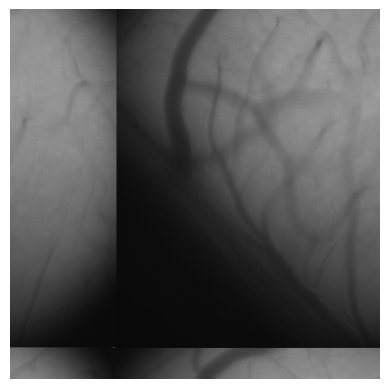

In [6]:
import subprocess
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

png_path = in_path.with_name(in_path.stem + "_t10.png")

cmd = [
    "ffmpeg","-y",
    "-i", str(in_path),
    "-ss","00:00:10",      # try 10s in
    "-frames:v","1",
    str(png_path)
]
p = subprocess.run(cmd, capture_output=True, text=True)
print("returncode:", p.returncode)
print("\n".join(p.stderr.splitlines()[-30:]))

img = Image.open(png_path)
plt.figure()
plt.imshow(img)
plt.axis("off")
plt.show()

In [8]:
import cv2, numpy as np, pandas as pd
from pathlib import Path

media = Path("miniscope-cam_0.avi")

cap = cv2.VideoCapture(str(media))
assert cap.isOpened(), "OpenCV couldn't open the video."

def seam_score(bgr, tile=64):
    g = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.int16)
    H, W = g.shape
    xs = range(tile, W, tile)
    ys = range(tile, H, tile)
    s = 0.0
    for x in xs:
        s += float(np.mean(np.abs(g[:, x] - g[:, x-1])))
    for y in ys:
        s += float(np.mean(np.abs(g[y, :] - g[y-1, :])))
    return s

step = 5          # scan every 5th frame for speed; set to 1 for full scan
tile = 64         # try 32/64/128 depending on your artifact scale

rows = []
n = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    if n % step == 0:
        rows.append((n, seam_score(frame, tile=tile)))
    n += 1
cap.release()

df = pd.DataFrame(rows, columns=["frame", "seam_score"]).sort_values("seam_score", ascending=False)
df.head(20)

,frame,seam_score
1097,5485,918.894737
3421,17105,610.802632
12715,63575,315.161184
8068,40340,145.399671
10392,51960,104.860197
5744,28720,57.902961
1283,6415,34.860197
3607,18035,34.832237
3606,18030,34.674342
3608,18040,34.672697


In [ ]:
import matplotlib.pyplot as plt

def show_frame(path, idx):
    cap = cv2.VideoCapture(str(path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, fr = cap.read()
    cap.release()
    if not ok:
        print("Could not read frame", idx)
        return
    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
    plt.title(f"frame {idx}")
    plt.axis("off")
    plt.show()

for idx in df["frame"].head(5):
    show_frame(media, int(idx))